In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import time, psutil
import optuna
from ray import tune
from ray.tune.schedulers import ASHAScheduler
from ray.tune.integration.keras import TuneReportCallback
from ray.tune import TuneConfig
from ray.tune import Tuner, TuneConfig
from ray.air.config import RunConfig
from ray.tune.progress_reporter import CLIReporter

c:\Users\ASUS ZENBOOK\inz\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-20 02:06:07,348	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-01-20 02:06:07,706	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-01-20 02:06:08,147	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:

# Parametry
N = 10000
rng = np.random.default_rng(42)

# Klasy: 0 - karpiowy, 1 - liniowy, 2 - pstrągowy
classes = rng.choice([0, 1, 2], size=N, p=[0.4, 0.35, 0.25])

# Cechy środowiskowe i biologiczne - bardziej nakładające się
temperatura = np.select([classes==0, classes==1, classes==2],
                        [rng.normal(20, 3, N), rng.normal(18, 3, N), rng.normal(15, 3, N)])
ph = np.select([classes==0, classes==1, classes==2],
               [rng.normal(7.3, 0.3, N), rng.normal(7.1, 0.3, N), rng.normal(6.9, 0.3, N)])
tlen = np.select([classes==0, classes==1, classes==2],
                 [rng.normal(6.8, 0.6, N), rng.normal(7.2, 0.6, N), rng.normal(7.8, 0.6, N)])
azotany = np.select([classes==0, classes==1, classes==2],
                    [rng.normal(2.8, 0.9, N), rng.normal(2.6, 0.9, N), rng.normal(2.0, 0.9, N)])
fosforany = np.select([classes==0, classes==1, classes==2],
                      [rng.normal(0.55, 0.2, N), rng.normal(0.5, 0.2, N), rng.normal(0.45, 0.2, N)])
przezroczystosc = np.select([classes==0, classes==1, classes==2],
                            [rng.normal(1.5, 0.4, N), rng.normal(1.6, 0.4, N), rng.normal(1.8, 0.4, N)])
gleba = np.select([classes==0, classes==1, classes==2],
                  [rng.normal(5.0, 1.2, N), rng.normal(4.8, 1.2, N), rng.normal(5.3, 1.2, N)])
powierzchnia = np.select([classes==0, classes==1, classes==2],
                         [rng.normal(2.2, 0.5, N), rng.normal(2.0, 0.5, N), rng.normal(2.4, 0.5, N)])
glebokosc = np.select([classes==0, classes==1, classes==2],
                      [rng.normal(1.8, 0.4, N), rng.normal(2.0, 0.4, N), rng.normal(2.3, 0.4, N)])
roslinnosc = np.select([classes==0, classes==1, classes==2],
                       [rng.normal(0.7, 0.2, N), rng.normal(0.8, 0.2, N), rng.normal(0.6, 0.2, N)])
przeplyw = np.select([classes==0, classes==1, classes==2],
                     [rng.normal(0.35, 0.1, N), rng.normal(0.4, 0.1, N), rng.normal(0.5, 0.1, N)])
srednia_waga_ryb = np.select([classes==0, classes==1, classes==2],
                             [rng.normal(1.0, 0.3, N), rng.normal(0.8, 0.3, N), rng.normal(0.6, 0.3, N)])

# DataFrame
df = pd.DataFrame({
    "temperatura_wody": temperatura,
    "pH": ph,
    "tlen": tlen,
    "azotany": azotany,
    "fosforany": fosforany,
    "przezroczystość": przezroczystosc,
    "gleba": gleba,
    "powierzchnia_stawu": powierzchnia,
    "głębokość": glebokosc,
    "roślinność": roslinnosc,
    "przepływ": przeplyw,
    "średnia_waga_ryb": srednia_waga_ryb,
    "typ_stawu": classes
})

df.head()


,temperatura_wody,pH,tlen,azotany,fosforany,przezroczystość,gleba,powierzchnia_stawu,głębokość,roślinność,przepływ,średnia_waga_ryb,typ_stawu
0,13.130020,7.310568,7.967733,0.908961,0.485740,1.533415,7.142764,2.445784,1.104145,1.006620,0.661675,0.405642,2
1,19.059878,7.889500,7.701760,4.252272,0.612896,1.742016,7.346519,2.897605,1.434205,1.242355,0.504070,0.902930,1
2,10.897911,7.196176,7.226915,1.166437,0.717741,1.742751,5.638979,1.826318,1.963133,0.668712,0.494104,0.484903,2
3,23.206871,6.824368,7.372442,2.893207,0.601915,1.255983,4.382673,1.525754,1.931104,0.579046,0.399120,0.934168,1
4,21.563828,7.328966,6.684946,1.986958,0.407372,1.615872,4.935692,2.614010,1.198554,0.478093,0.221704,0.939020,0


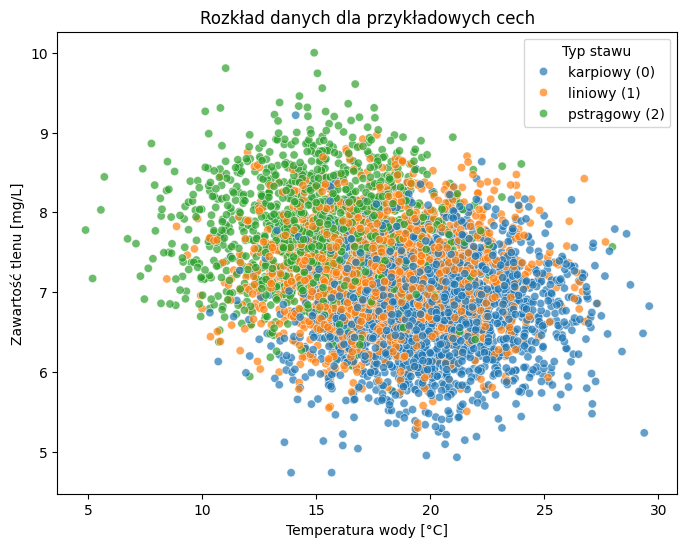

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_df = df.sample(5000, random_state=42)

palette_map = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=sample_df,
    x="temperatura_wody",
    y="tlen",
    hue="typ_stawu",
    palette=palette_map,
    alpha=0.7
)

# poprawia opisy w legendzie bez psucia kolorów
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=["karpiowy (0)", "liniowy (1)", "pstrągowy (2)"], title="Typ stawu")

plt.title("Rozkład danych dla przykładowych cech")
plt.xlabel("Temperatura wody [°C]")
plt.ylabel("Zawartość tlenu [mg/L]")
plt.show()


In [4]:
#zaokrąglenie dla czytelności
df = df.round(3)
df.head()

,temperatura_wody,pH,tlen,azotany,fosforany,przezroczystość,gleba,powierzchnia_stawu,głębokość,roślinność,przepływ,średnia_waga_ryb,typ_stawu
0,13.130,7.311,7.968,0.909,0.486,1.533,7.143,2.446,1.104,1.007,0.662,0.406,2
1,19.060,7.890,7.702,4.252,0.613,1.742,7.347,2.898,1.434,1.242,0.504,0.903,1
2,10.898,7.196,7.227,1.166,0.718,1.743,5.639,1.826,1.963,0.669,0.494,0.485,2
3,23.207,6.824,7.372,2.893,0.602,1.256,4.383,1.526,1.931,0.579,0.399,0.934,1
4,21.564,7.329,6.685,1.987,0.407,1.616,4.936,2.614,1.199,0.478,0.222,0.939,0


In [5]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temperatura_wody    10000 non-null  float64
 1   pH                  10000 non-null  float64
 2   tlen                10000 non-null  float64
 3   azotany             10000 non-null  float64
 4   fosforany           10000 non-null  float64
 5   przezroczystość     10000 non-null  float64
 6   gleba               10000 non-null  float64
 7   powierzchnia_stawu  10000 non-null  float64
 8   głębokość           10000 non-null  float64
 9   roślinność          10000 non-null  float64
 10  przepływ            10000 non-null  float64
 11  średnia_waga_ryb    10000 non-null  float64
 12  typ_stawu           10000 non-null  int64  
dtypes: float64(12), int64(1)
memory usage: 1015.8 KB
None


In [6]:
print(df.describe().T)

                      count       mean       std    min       25%      50%  \
temperatura_wody    10000.0  18.097343  3.600664  4.744  15.65975  18.1720   
pH                  10000.0   7.129347  0.336918  5.844   6.90100   7.1280   
tlen                10000.0   7.181230  0.723651  4.734   6.68375   7.1570   
azotany             10000.0   2.542171  0.959660 -1.312   1.87900   2.5480   
fosforany           10000.0   0.509748  0.204622 -0.255   0.37300   0.5140   
przezroczystość     10000.0   1.612321  0.419023  0.155   1.32500   1.6080   
gleba               10000.0   5.004868  1.208973 -0.914   4.20400   5.0260   
powierzchnia_stawu  10000.0   2.183831  0.523507  0.171   1.82575   2.1840   
głębokość           10000.0   1.996999  0.448564  0.266   1.68900   1.9870   
roślinność          10000.0   0.709666  0.211412 -0.071   0.56700   0.7070   
przepływ            10000.0   0.403596  0.115413  0.016   0.32475   0.4000   
średnia_waga_ryb    10000.0   0.828193  0.338294 -0.335   0.5960

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Podział 70/30: trening/test
X = df.drop(columns=["typ_stawu"])
y = df["typ_stawu"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# walidacja wydzielona z treningu  20% z treningu)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

print("Treningowe:", X_train.shape)
print("Walidacyjne:", X_val.shape)
print("Testowe:", X_test.shape)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_val_scaled   = scaler.transform(X_val)
x_test_scaled  = scaler.transform(X_test)


Treningowe: (5600, 12)
Walidacyjne: (1400, 12)
Testowe: (3000, 12)


## Bazowy model MLP

In [ ]:
start = time.perf_counter()
process = psutil.Process()

model = keras.Sequential([
    layers.Input(shape=(x_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train_scaled, y_train,
    validation_data=(x_val_scaled, y_val), 
    epochs=30,
    batch_size=64,
    verbose=1,
    callbacks=[callback]
)

elapsed = time.perf_counter() - start
mem_used = process.memory_info().rss / (1024 * 1024)

print(f"Czas uczenia: {elapsed:.2f}s")
print(f"Zużycie pamięci: {mem_used:.2f} MB")

# Ocena na zbiorze testowym (tylko na końcu)
test_loss, test_acc = model.evaluate(x_test_scaled, y_test, verbose=0)
print(f"Wynik testowy - loss: {test_loss:.4f}, accuracy: {test_acc:.4f}")


Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5323 - loss: 0.9208 - val_accuracy: 0.7086 - val_loss: 0.6948
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7180 - loss: 0.6399 - val_accuracy: 0.7707 - val_loss: 0.5321
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7611 - loss: 0.5500 - val_accuracy: 0.7836 - val_loss: 0.4909
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7711 - loss: 0.5218 - val_accuracy: 0.7943 - val_loss: 0.4793
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7782 - loss: 0.5031 - val_accuracy: 0.7950 - val_loss: 0.4699
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7752 - loss: 0.5018 - val_accuracy: 0.7957 - val_loss: 0.4725
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7818 - loss: 0.4989 - val_accuracy: 0.7950 - val_loss: 0.4657
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7814 - loss: 0.4868 - val_accuracy: 0.7907 - val_loss:

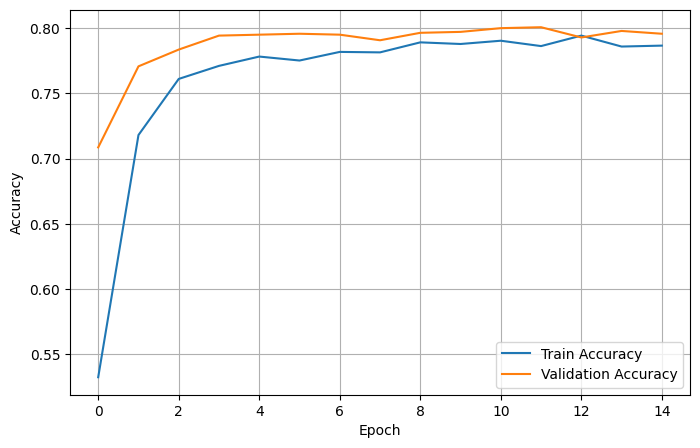

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


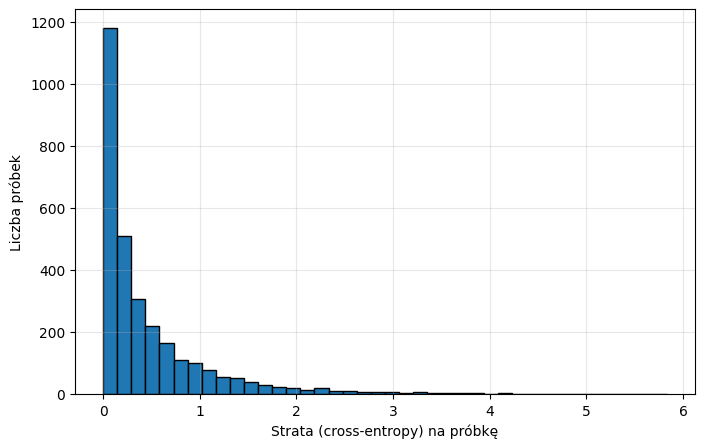

In [11]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# predykcje prawdopodobieństw klas
y_prob = model.predict(x_test_scaled, verbose=0)

# loss dla każdej próbki (bez uśredniania)
sce = tf.keras.losses.SparseCategoricalCrossentropy(reduction=tf.keras.losses.Reduction.NONE)
loss_per_sample = sce(y_test, y_prob).numpy()

plt.figure(figsize=(8, 5))
plt.hist(loss_per_sample, bins=40, edgecolor='black')
plt.xlabel("Strata (cross-entropy) na próbkę")
plt.ylabel("Liczba próbek")
plt.grid(True, alpha=0.3)
plt.show()


## Random Search

In [33]:
def build_model(hp):
    model = keras.Sequential([
        layers.Input(shape=(x_train_scaled.shape[1],)),

        # Pierwsza warstwa
        layers.Dense(
            units=hp.Int('units_1', min_value=32, max_value=256, step=32),
            activation='relu'
        ),

        # Dropout
        layers.Dropout(
            rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
        ),

        # Druga warstwa
        layers.Dense(
            units=hp.Int('units_2', min_value=16, max_value=256, step=16),
            activation='relu'
        ),

        layers.Dense(3, activation='softmax')
    ])

    # batch_size jako hiperparametr
    hp.Choice('batch_size', values=[32, 64, 128, 256])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Float('lr', 1e-5, 1e-2, sampling='log')
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory="C:\\Users\\ASUS ZENBOOK\\Desktop\\tuning_results",
    project_name='random_search71'
)

callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

start = time.perf_counter()
process = psutil.Process()

tuner.search(
    x_train_scaled, y_train,
    validation_data=(x_val_scaled, y_val),   
    epochs=30,
    callbacks=[callback],
    verbose=1
)

elapsed = time.perf_counter() - start
mem_used = process.memory_info().rss / (1024 * 1024)

best_hp = tuner.get_best_hyperparameters(1)[0]
best_batch = best_hp.get('batch_size')
print(f"\nWybrany batch_size: {best_batch}")

best_model = tuner.hypermodel.build(best_hp)
history = best_model.fit(
    x_train_scaled, y_train,
    validation_data=(x_val_scaled, y_val),
    epochs=30,
    batch_size=best_batch,
    callbacks=[callback],
    verbose=0
)


# OCENA NA ZBIORZE TESTOWYM (tylko na końcu)
test_loss, test_acc = best_model.evaluate(x_test_scaled, y_test, verbose=0)

print("\n=== RANDOM SEARCH (MLP) ===")
print("Najlepsze hiperparametry:")
for param, value in best_hp.values.items():
    print(f"  {param}: {value}")

print(f"Wynik walidacyjny (val_accuracy z tunera): {best_hp.get('val_accuracy') if 'val_accuracy' in best_hp.values else 'sprawdź w logach'}")
print(f"Wynik testowy accuracy: {test_acc:.4f}")
print(f"Czas przeszukiwania: {elapsed:.2f} s | Zużycie pamięci: {mem_used:.2f} MB")


Trial 10 Complete [00h 00m 09s]
val_accuracy: 0.7964285612106323

Best val_accuracy So Far: 0.802142858505249
Total elapsed time: 00h 02m 36s

Wybrany batch_size: 128

=== RANDOM SEARCH (MLP) ===
Najlepsze hiperparametry:
  units_1: 128
  dropout: 0.1
  units_2: 144
  batch_size: 128
  lr: 6.934958692471433e-05
Wynik walidacyjny (val_accuracy z tunera): sprawdź w logach
Wynik testowy accuracy: 0.7843
Czas przeszukiwania: 155.99 s | Zużycie pamięci: 1034.22 MB


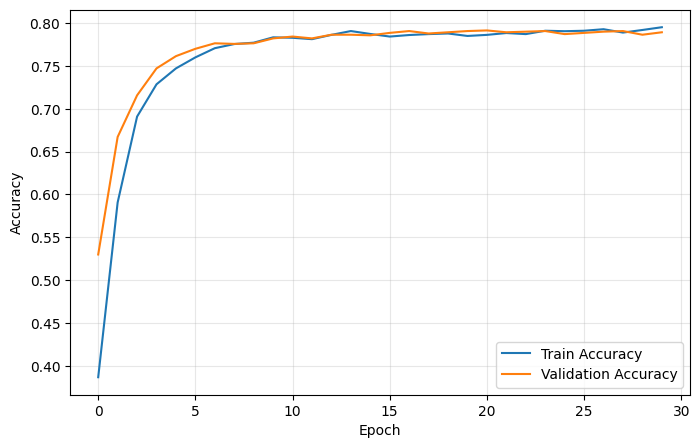

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


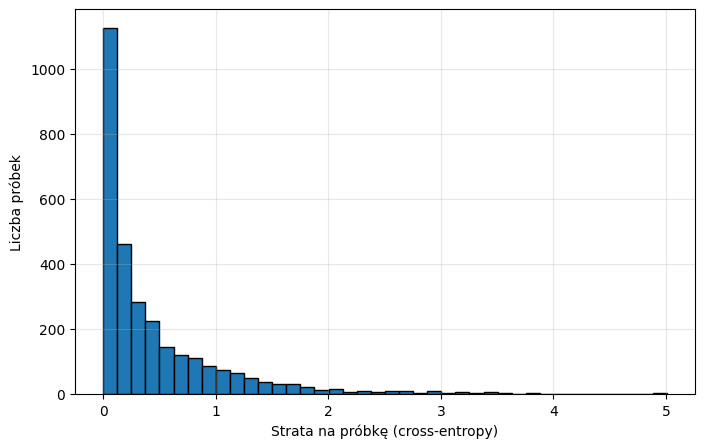

In [35]:
import tensorflow as tf

y_prob = best_model.predict(x_test_scaled, verbose=0)

sce = tf.keras.losses.SparseCategoricalCrossentropy(
    reduction=tf.keras.losses.Reduction.NONE
)
loss_per_sample = sce(y_test, y_prob).numpy()

plt.figure(figsize=(8, 5))
plt.hist(loss_per_sample, bins=40, edgecolor='black')
plt.xlabel("Strata na próbkę (cross-entropy)")
plt.ylabel("Liczba próbek")

plt.grid(True, alpha=0.3)
plt.show()


## Hyperband 

In [24]:
def build_model(hp):
    model = keras.Sequential([
        layers.Input(shape=(x_train_scaled.shape[1],)),

        # Pierwsza warstwa ukryta
        layers.Dense(
            units=hp.Int('units_1', min_value=32, max_value=256, step=32),
            activation='relu'
        ),

        # Dropout
        layers.Dropout(
            rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
        ),

        # Druga warstwa ukryta
        layers.Dense(
            units=hp.Int('units_2', min_value=16, max_value=128, step=16),
            activation='relu'
        ),

        layers.Dense(3, activation='softmax')
    ])

    hp.Choice('batch_size', values=[32, 64, 128, 256])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Float('lr', 1e-5, 1e-2, sampling='log')
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=30,
    factor=3,
    directory="C:\\Users\\ASUS ZENBOOK\\Desktop\\tuning_results",
    project_name='hyperband4'
)

callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

start = time.perf_counter()
process = psutil.Process()

tuner.search(
    x_train_scaled, y_train,
    validation_data=(x_val_scaled, y_val),   
    epochs=30,
    callbacks=[callback],
    verbose=1
)

elapsed = time.perf_counter() - start
mem_used = process.memory_info().rss / (1024 * 1024)

best_hp = tuner.get_best_hyperparameters(1)[0]
best_batch = best_hp.get('batch_size')
print(f"\nWybrany batch_size: {best_batch}")

best_model = tuner.hypermodel.build(best_hp)

history = best_model.fit(
    x_train_scaled, y_train,
    validation_data=(x_val_scaled, y_val), 
    epochs=30,
    batch_size=best_batch,
    callbacks=[callback],
    verbose=0
)

# OCENA NA ZBIORZE TESTOWYM (tylko na końcu)
test_loss, test_acc = best_model.evaluate(x_test_scaled, y_test, verbose=0)

print("\n=== HYPERBAND (MLP) ===")
print("Najlepsze hiperparametry:")
for param, value in best_hp.values.items():
    print(f"  {param}: {value}")

print(f"Wynik testowy accuracy: {test_acc:.4f}")
print(f"Czas przeszukiwania: {elapsed:.2f} s | Zużycie pamięci: {mem_used:.2f} MB")


Trial 90 Complete [00h 00m 21s]
val_accuracy: 0.7907142639160156

Best val_accuracy So Far: 0.8042857050895691
Total elapsed time: 00h 08m 25s

Wybrany batch_size: 128

=== HYPERBAND (MLP) ===
Najlepsze hiperparametry:
  units_1: 64
  dropout: 0.2
  units_2: 80
  batch_size: 128
  lr: 0.0009263485888908177
  tuner/epochs: 30
  tuner/initial_epoch: 10
  tuner/bracket: 3
  tuner/round: 3
  tuner/trial_id: 0047
Wynik testowy accuracy: 0.7887
Czas przeszukiwania: 504.53 s | Zużycie pamięci: 1324.61 MB


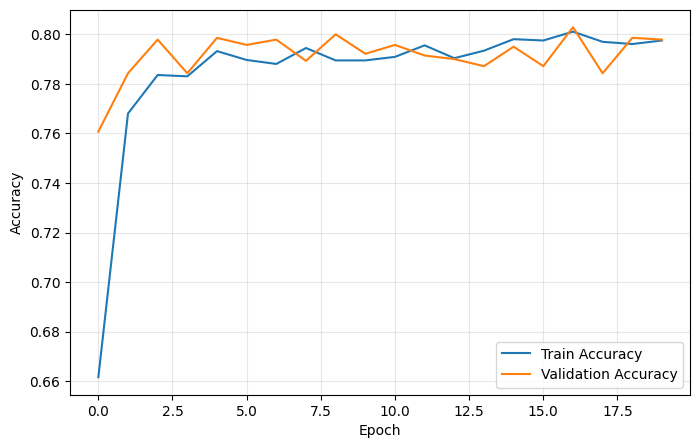

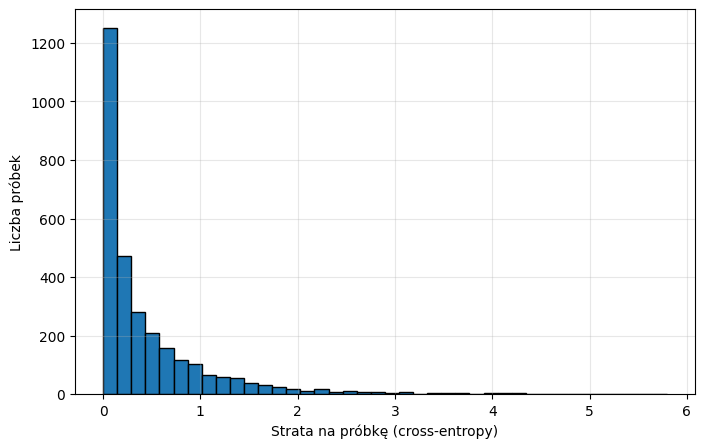

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

import tensorflow as tf

y_prob = best_model.predict(x_test_scaled, verbose=0)

sce = tf.keras.losses.SparseCategoricalCrossentropy(
    reduction=tf.keras.losses.Reduction.NONE
)
loss_per_sample = sce(y_test, y_prob).numpy()

plt.figure(figsize=(8, 5))
plt.hist(loss_per_sample, bins=40, edgecolor='black')
plt.xlabel("Strata na próbkę (cross-entropy)")
plt.ylabel("Liczba próbek")
plt.grid(True, alpha=0.3)
plt.show()


## Optuna


In [27]:
def objective(trial):
    n_units_1 = trial.suggest_int('units_1', 32, 256, step=32)
    n_units_2 = trial.suggest_int('units_2', 16, 256, step=16)
    dropout = trial.suggest_float('dropout', 0.1, 0.5, step=0.1)
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])

    model = keras.Sequential([
        layers.Input(shape=(x_train_scaled.shape[1],)),
        layers.Dense(n_units_1, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(n_units_2, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callback = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        x_train_scaled, y_train,
        validation_data=(x_val_scaled, y_val), 
        epochs=30,
        batch_size=batch_size,
        callbacks=[callback],
        verbose=0
    )

    return max(history.history['val_accuracy'])


start = time.perf_counter()
process = psutil.Process()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

elapsed = time.perf_counter() - start
mem_used = process.memory_info().rss / (1024 * 1024)

print("\n=== OPTUNA (MLP) ===")
print("Najlepsze hiperparametry:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

print(f"Najlepszy wynik walidacyjny: {study.best_value:.4f}")
print(f"Czas przeszukiwania: {elapsed:.2f} s | Zużycie pamięci: {mem_used:.2f} MB")

# trening finalnego modelu na najlepszych HP i test na końcu:
best_params = study.best_params

best_model = keras.Sequential([
    layers.Input(shape=(x_train_scaled.shape[1],)),
    layers.Dense(best_params['units_1'], activation='relu'),
    layers.Dropout(best_params['dropout']),
    layers.Dense(best_params['units_2'], activation='relu'),
    layers.Dense(3, activation='softmax')
])

best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_params['lr']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callback_final = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = best_model.fit(
    x_train_scaled, y_train,
    validation_data=(x_val_scaled, y_val),
    epochs=30,
    batch_size=best_params['batch_size'],
    callbacks=[callback_final],
    verbose=0
)

test_loss, test_acc = best_model.evaluate(x_test_scaled, y_test, verbose=0)
print(f"Wynik testowy accuracy: {test_acc:.4f}")


[I 2026-01-20 08:09:26,123] A new study created in memory with name: no-name-6b912d48-b983-4890-a326-cc9009ea32f2
[I 2026-01-20 08:09:36,569] Trial 0 finished with value: 0.7900000214576721 and parameters: {'units_1': 160, 'units_2': 80, 'dropout': 0.2, 'lr': 2.1948071572009526e-05, 'batch_size': 64}. Best is trial 0 with value: 0.7900000214576721.
[I 2026-01-20 08:09:42,244] Trial 1 finished with value: 0.7964285612106323 and parameters: {'units_1': 224, 'units_2': 208, 'dropout': 0.2, 'lr': 0.0003441994261019499, 'batch_size': 256}. Best is trial 1 with value: 0.7964285612106323.
[I 2026-01-20 08:09:45,066] Trial 2 finished with value: 0.8014285564422607 and parameters: {'units_1': 96, 'units_2': 80, 'dropout': 0.30000000000000004, 'lr': 0.004272478178216552, 'batch_size': 256}. Best is trial 2 with value: 0.8014285564422607.
[I 2026-01-20 08:10:02,328] Trial 3 finished with value: 0.7964285612106323 and parameters: {'units_1': 160, 'units_2': 128, 'dropout': 0.1, 'lr': 5.24734254796


=== OPTUNA (MLP) ===
Najlepsze hiperparametry:
  units_1: 32
  units_2: 224
  dropout: 0.1
  lr: 0.0015424266424806737
  batch_size: 64
Najlepszy wynik walidacyjny: 0.8021
Czas przeszukiwania: 77.23 s | Zużycie pamięci: 1494.86 MB
Wynik testowy accuracy: 0.7887


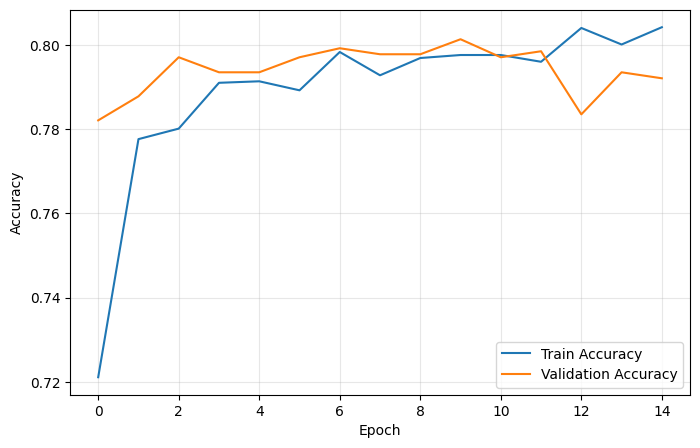

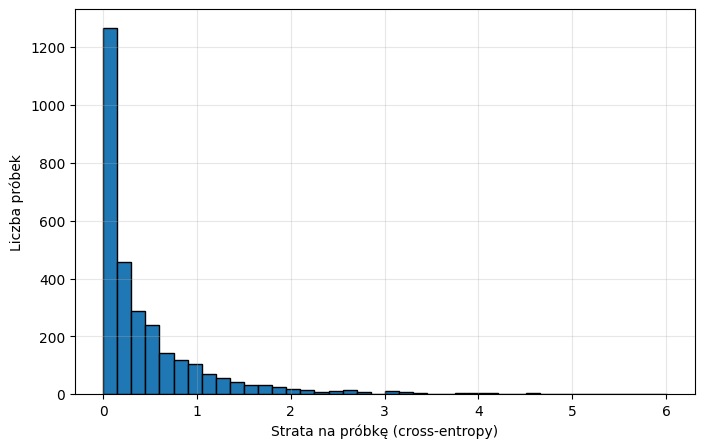

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

import tensorflow as tf

y_prob = best_model.predict(x_test_scaled, verbose=0)

sce = tf.keras.losses.SparseCategoricalCrossentropy(
    reduction=tf.keras.losses.Reduction.NONE
)
loss_per_sample = sce(y_test, y_prob).numpy()

plt.figure(figsize=(8, 5))
plt.hist(loss_per_sample, bins=40, edgecolor='black')
plt.xlabel("Strata na próbkę (cross-entropy)")
plt.ylabel("Liczba próbek")
plt.grid(True, alpha=0.3)
plt.show()


## Ray Tune

In [30]:
from ray.air import session

In [31]:
def build_model(config):
    model = keras.Sequential([
        layers.Input(shape=(x_train_scaled.shape[1],)),
        layers.Dense(config["units_1"], activation="relu"),
        layers.Dropout(config["dropout"]),
        layers.Dense(config["units_2"], activation="relu"),
        layers.Dense(3, activation="softmax")
    ])
    opt = keras.optimizers.Adam(learning_rate=config["lr"])
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


start = time.perf_counter()
process = psutil.Process()


def train_model(config):
    model = build_model(config)

    es = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        x_train_scaled, y_train,
        validation_data=(x_val_scaled, y_val),  
        epochs=30,
        batch_size=config["batch_size"],
        verbose=0,
        callbacks=[es]
    )

    val_acc = float(np.nanmax(history.history["val_accuracy"]))
    session.report({"val_accuracy": val_acc})


param_space = {
    "units_1": tune.choice([32, 64, 128]),
    "units_2": tune.choice([16, 32, 64]),
    "dropout": tune.uniform(0.1, 0.5),
    "lr": tune.loguniform(1e-5, 1e-2),
    "batch_size": tune.choice([32, 64, 128, 256]),
}

tuner = Tuner(
    tune.with_parameters(train_model),
    param_space=param_space,
    tune_config=TuneConfig(
        metric="val_accuracy",
        mode="max",
        num_samples=20,
    ),
)

results = tuner.fit()

elapsed = time.perf_counter() - start
mem_used = process.memory_info().rss / (1024 * 1024)

best_result = results.get_best_result(metric="val_accuracy", mode="max")

print("\n=== RAY TUNE (MLP) ===")
print("Najlepsze hiperparametry:", best_result.config)
print("Najlepszy wynik walidacyjny:", best_result.metrics["val_accuracy"])
print(f"\nCzas uczenia: {elapsed:.2f}s")
print(f"Zużycie pamięci: {mem_used:.2f} MB")

#trening finalny na najlepszych HP i test na końcu:
best_config = best_result.config
best_model = build_model(best_config)

es_final = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = best_model.fit(
    x_train_scaled, y_train,
    validation_data=(x_val_scaled, y_val),
    epochs=30,
    batch_size=best_config["batch_size"],
    verbose=0,
    callbacks=[es_final]
)

test_loss, test_acc = best_model.evaluate(x_test_scaled, y_test, verbose=0)
print(f"Wynik testowy accuracy: {test_acc:.4f}")


2026-01-20 08:18:13,808	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\ASUSZE~1\AppData\Local\Temp\ray\session_2026-01-20_08-16-14_128486_45384\artifacts\2026-01-20_08-18-13\train_model_2026-01-20_08-18-13\driver_artifacts\train_model_2eba1_00000_0_batch_size=128,dropout=0.4168,lr=0.0001,units_1=32,units_2=64_2026-01-20_08-18-13
2026-01-20 08:18:13,835	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\ASUSZE~1\AppData\Local\Temp\ray\session_2026-01-20_08-16-14_128486_45384\artifacts\2026-01-20_08-18-13\train_model_2026-01-20_08-18-13\driver_artifacts\train_model_2eba1_00000_0_batch_size=128,dropout=0.4168,lr=0.0001,units_1=32,units_2=64_2026-01-20_08-18-13
2026-01-20 08:18:13,842	WARNING trial.py:647 -- The path to the trial log directory is too long (max l


=== RAY TUNE (MLP) ===
Najlepsze hiperparametry: {'units_1': 64, 'units_2': 32, 'dropout': 0.25176954798121265, 'lr': 0.0008932002445812695, 'batch_size': 256}
Najlepszy wynik walidacyjny: 0.8035714030265808

Czas uczenia: 54.96s
Zużycie pamięci: 1509.15 MB
Wynik testowy accuracy: 0.7850


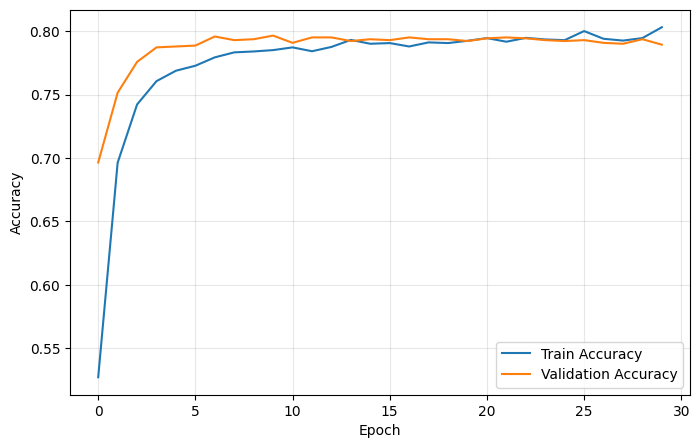

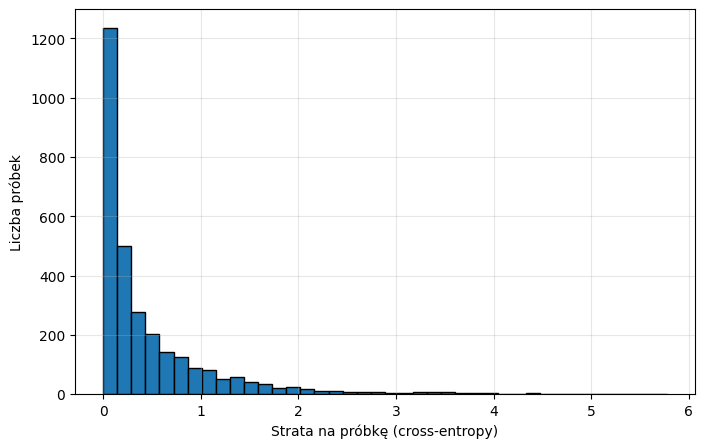

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

import tensorflow as tf

y_prob = best_model.predict(x_test_scaled, verbose=0)

sce = tf.keras.losses.SparseCategoricalCrossentropy(
    reduction=tf.keras.losses.Reduction.NONE
)
loss_per_sample = sce(y_test, y_prob).numpy()

plt.figure(figsize=(8, 5))
plt.hist(loss_per_sample, bins=40, edgecolor='black')
plt.xlabel("Strata na próbkę (cross-entropy)")
plt.ylabel("Liczba próbek")
plt.grid(True, alpha=0.3)
plt.show()
